# Partiels - Programmation en langage Python - J5P22615

In [1]:
import pandas as pd

# 1. Charger le fichier: ``data_partiels.csv`` dans un DataFrame Pandas. Que contient ce dataframe ? Quelle est la taille de ce DataFrame ? (le nombre de lignes et de colonnes) _(0.5 points)_

df = pd.read_csv("data_partiels.csv")

df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19.0,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22.0,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20.0,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18.0,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21.0,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [2]:
df.shape

(705, 13)

In [3]:
df.agg(
    {
        "Age": ["min", "max", "mean", "std"],
    }
)

,Age
min,18.000000
max,24.000000
mean,20.662873
std,1.399583


In [4]:
# 2. Créer un nouveau dataframe à partir DU DataFrame chargé à la question 1, en ne gardant que les colonnes suivantes, en les renommant: _(0.5 point)_

columns_mapping = {
    "Student_ID": "etudiant_id",
    "Age": "age",
    "Gender": "genre",
    "Avg_Daily_Usage_Hours": "utilisation_horaire_moyenne_jour",
    "Most_Used_Platform": "plateforme_principale",
    "Sleep_Hours_Per_Night": "heures_de_sommeil_par_nuit",
    "Addicted_Score": "score_addiction",
    "Mental_Health_Score": "score_sante_mentale",
}

df = df.rename(columns=columns_mapping)
df = df[list(columns_mapping.values())]

In [5]:
df

,etudiant_id,age,genre,utilisation_horaire_moyenne_jour,plateforme_principale,heures_de_sommeil_par_nuit,score_addiction,score_sante_mentale
0,1,19.0,Female,5.2,Instagram,6.5,8,6
1,2,22.0,Male,2.1,Twitter,7.5,3,8
2,3,20.0,Female,6.0,TikTok,5.0,9,5
3,4,18.0,Male,3.0,YouTube,7.0,4,7
4,5,21.0,Male,4.5,Facebook,6.0,7,6
...,...,...,...,...,...,...,...,...
700,701,20.0,Female,4.7,TikTok,7.2,5,7
701,702,23.0,Male,6.8,Instagram,5.9,9,4
702,703,21.0,Female,5.6,WeChat,6.7,7,6
703,704,24.0,Male,4.3,Twitter,7.5,4,8


In [6]:
# 3. Créez une fonction Python qui prend en entrée une Series Pandas et retourne
# la moyenne de cette série. La fonction doit d'abord vérifier la présence de valeurs
# nulles dans la Series. Si des valeurs nulles sont détectées, la fonction doit afficher
# un message d'avertissement précisant le nom de la série concernée, puis remplacer ces
# valeurs nulles par la moyenne de la série avant d'effectuer les calculs.
# Appliquez ensuite cette fonction aux colonnes 'utilisation_horaire_moyenne_jour' et
# 'age' du DataFrame que vous avez créé précédemment.
# Quel est l'âge moyen ? Et l’utilisation horaire moyenne par jour ?


def calculate_mean(series: pd.Series) -> float:
    """Calcule la moyenne d'une série Pandas, en gérant les valeurs nulles.
    :param series: La série Pandas à analyser.
    :return: La moyenne de la série, après traitement des valeurs nulles.
    """
    if series.isnull().any():
        print(f"Avertissement: La série '{series.name}' contient des valeurs nulles.")
        series.fillna(series.mean(), inplace=True)
    return series.mean()

In [7]:
calculate_mean(df["utilisation_horaire_moyenne_jour"])

np.float64(4.918723404255319)

In [8]:
calculate_mean(df["age"])

Avertissement: La série 'age' contient des valeurs nulles.


np.float64(20.662873399715505)

In [23]:
# 4. Pour les étudiants dont la plateforme principale est TikTok,
# quelle est l'utilisation moyenne horaire journalière ?
# Comment varie-t-il selon le genre ? _(1 point)_
df_tiktok = df[df["plateforme_principale"] == "TikTok"]
df_tiktok["utilisation_horaire_moyenne_jour"].mean()

np.float64(5.346103896103896)

In [24]:
df_tiktok.groupby("genre")["utilisation_horaire_moyenne_jour"].mean()

genre
Female    5.606977
Male      5.016176
Name: utilisation_horaire_moyenne_jour, dtype: float64

In [18]:
(df_plateforme_instagram["heures_de_sommeil_par_nuit"] < 7).count()

np.int64(249)

In [21]:
# 5. Quel est le pourcentage d'étudiants dont la plateforme principale est
# Instagram et qui ont un temps de sommeil inférieur à 7 heures par nuit ? _(1 point)_
df_plateforme_instagram = df[df["plateforme_principale"] == "Instagram"]
pourcentage_sommeil_inferieur_7h = (
    df_plateforme_instagram[
        df_plateforme_instagram["heures_de_sommeil_par_nuit"] < 7
    ].shape[0]
    / len(df)
    * 100
)

In [22]:
pourcentage_sommeil_inferieur_7h

16.170212765957448

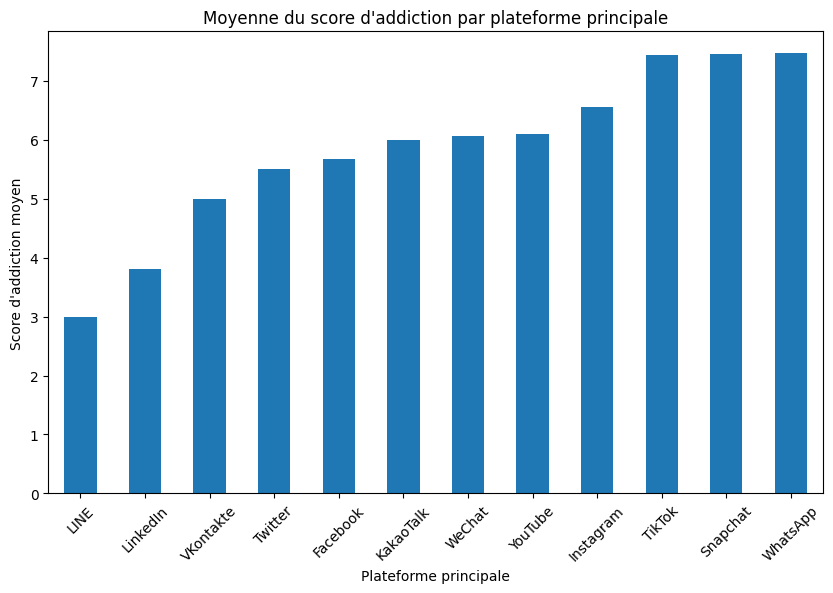

In [12]:
# 6. Créez un graphique montrant la moyenne du score d'addiction par plateforme principale. _(1 point)_
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.groupby("plateforme_principale")["score_addiction"].mean().sort_values().plot(
    kind="bar"
)
plt.title("Moyenne du score d'addiction par plateforme principale")
plt.xlabel("Plateforme principale")
plt.ylabel("Score d'addiction moyen")
plt.xticks(rotation=45)
plt.show()

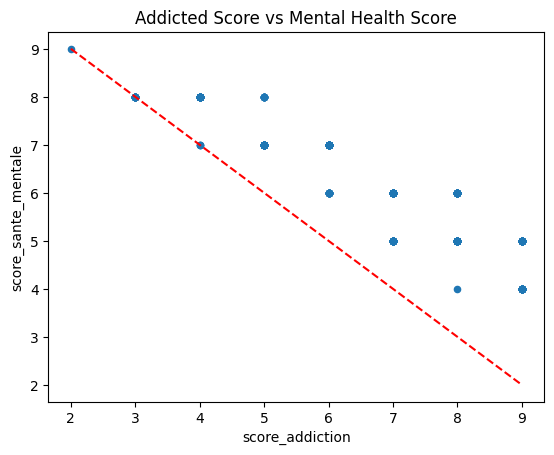

In [13]:
# 7. Créez un graphique montrant la relation entre le score d'addiction et le score de santé mentale. Commentez ce graphique. _(1 point)_
df.plot.scatter(
    x="score_addiction",
    y="score_sante_mentale",
    title="Addicted Score vs Mental Health Score",
)
min_val = min(df["score_addiction"].min(), df["score_sante_mentale"].min())
max_val = max(df["score_addiction"].max(), df["score_sante_mentale"].max())
plt.plot([min_val, max_val], [max_val, min_val], color="red", linestyle="--")
plt.show()

In [14]:
# **Bonus: _(1.5 point)_**
# 1. Quel est le score R² du modèle de régression linéaire entre le score d'addiction et le score de santé mentale ? _(1 point)_
from sklearn.linear_model import LinearRegression

X = df[["score_addiction"]]
y = df["score_sante_mentale"]

model = LinearRegression()
model.fit(X, y)

model.score(X, y)

0.8931207796934594

In [15]:
x = 0
while x < 10:
    x += 1
    print(x)

1
2
3
4
5
6
7
8
9
10
